In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import time
import tensorflow as tf
import tensorflow.python.keras
import matplotlib.pyplot as plt


2025-11-05 01:48:07.757868: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762307287.779918  544775 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762307287.786868  544775 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-05 01:48:07.810541: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from glob import glob

In [3]:
IMAGE_SIZE = [224,224]

In [4]:
# Create InceptionV3 Layer
rn = ResNet50(include_top=False,weights='imagenet',input_shape=IMAGE_SIZE + [3])
for layer in rn.layers:
  layer.trainable = False

W0000 00:00:1762307290.185716  544775 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


       0/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   40960/94765736 ━━━━━━━━━━━━━━━━━━━━ 2:00 1us/step

   49152/94765736 ━━━━━━━━━━━━━━━━━━━━ 6:56 4us/step

   81920/94765736 ━━━━━━━━━━━━━━━━━━━━ 7:45 5us/step

...

92880896/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

93421568/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

94289920/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

94765056/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [5]:
# we will use the glob to see how many outputs / labels there are
folders = glob('./plantvillage/*')

In [6]:
folders

['./plantvillage/Tomato___Bacterial_spot',
 './plantvillage/Tomato___Leaf_Mold',
 './plantvillage/Tomato___Septoria_leaf_spot',
 './plantvillage/Tomato___Spider_mites Two-spotted_spider_mite',
 './plantvillage/Tomato___Early_blight',
 './plantvillage/Tomato___Tomato_mosaic_virus',
 './plantvillage/Tomato___healthy',
 './plantvillage/Tomato___Late_blight',
 './plantvillage/Tomato___Target_Spot',
 './plantvillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus']

In [7]:
# Add Flatten and Dense in last layers
x = GlobalAveragePooling2D()(rn.output)
x = Dropout(0.5)(x)
prediction = Dense(len(folders),activation='softmax')(x)

In [8]:
model = Model(inputs=rn.input,outputs = prediction)
plot_model(model)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
# Compile the model that we have created with adam and the loss is categorical_crossentropy because the classification is more than 2 classes
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [11]:
# Then use the CustomImageDataGenerator instead of ImageDataGenerator
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255,
    rotation_range=10,           # Very small rotations
    width_shift_range=0.05,      # Minimal shifts
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,              # Small zoom
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)
test_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

In [12]:
# Load training and validation data using tf.data.Dataset
training_set = train_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='training',
    shuffle = True
)

val_set = val_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='validation'
)

test_dataset = test_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size = 8,
    class_mode = 'categorical',
    shuffle = False

)


Found 10288 images belonging to 10 classes.


Found 2567 images belonging to 10 classes.


Found 12855 images belonging to 10 classes.


In [13]:
print(training_set)
print(val_set)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [15]:
tic = time.perf_counter()
history = model.fit(training_set,
                    steps_per_epoch=len(training_set),
                    validation_data=val_set,
                    validation_steps=len(val_set),
                    epochs=20, callbacks=[early_stopping, reduce_lr])
# time
toc = time.perf_counter()
model.save('resnet50test.keras')


Epoch 1/20


/srv/conda/envs/datpham/emotion/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


   1/1286 ━━━━━━━━━━━━━━━━━━━━ 2:03:12 6s/step - accuracy: 0.1250 - loss: 2.8783

   2/1286 ━━━━━━━━━━━━━━━━━━━━ 5:03 236ms/step - accuracy: 0.0938 - loss: 2.9550

   3/1286 ━━━━━━━━━━━━━━━━━━━━ 5:03 236ms/step - accuracy: 0.0764 - loss: 2.9991

...

1285/1286 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.4218 - loss: 1.7030

1286/1286 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.4218 - loss: 1.7030

1286/1286 ━━━━━━━━━━━━━━━━━━━━ 379s 294ms/step - accuracy: 0.4218 - loss: 1.7030 - val_accuracy: 0.4616 - val_loss: 1.5364 - learning_rate: 0.0010


Epoch 20/20


1286/1286 ━━━━━━━━━━━━━━━━━━━━ 0s 22us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 0.0010


In [16]:
print("Total Time:{}".format(round((toc-tic)/60,2)))

Total Time:73.43


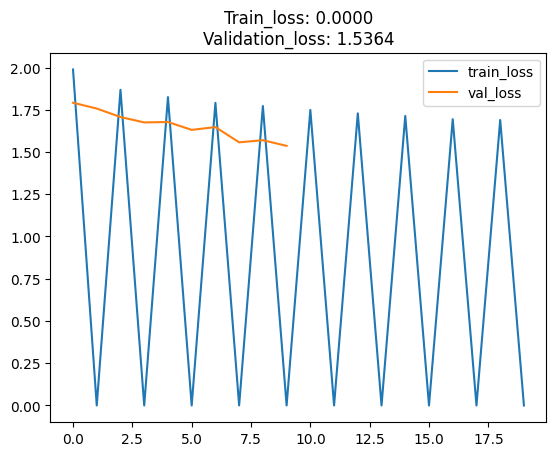

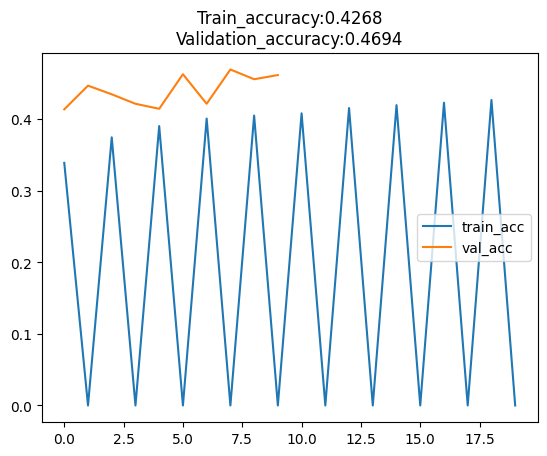

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(loss, label='train_loss')
plt.plot(val_loss,label = 'val_loss')
plt.legend()
plt.title("Train_loss: {:.4f}".format(history.history['loss'][-1]) +
          "\nValidation_loss: {:.4f}".format(history.history['val_loss'][-1]))
plt.savefig('resnet50_loss.png', dpi=150, bbox_inches='tight')
plt.show()

plt.plot(acc, label='train_acc')
plt.plot(val_acc,label = 'val_acc')
plt.title("Train_accuracy:{:.4f}".format(max(history.history['accuracy']))+
         "\nValidation_accuracy:{:.4f}".format(max(history.history['val_accuracy'])))
plt.legend()
plt.savefig('resnet50_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
scores = model.evaluate(test_dataset)

   1/1607 ━━━━━━━━━━━━━━━━━━━━ 7:06 266ms/step - accuracy: 0.0000e+00 - loss: 4.8242

   2/1607 ━━━━━━━━━━━━━━━━━━━━ 6:02 226ms/step - accuracy: 0.0000e+00 - loss: 4.8276

   3/1607 ━━━━━━━━━━━━━━━━━━━━ 6:20 237ms/step - accuracy: 0.0000e+00 - loss: 4.8394

   4/1607 ━━━━━━━━━━━━━━━━━━━━ 6:21 238ms/step - accuracy: 0.0000e+00 - loss: 4.8114

   5/1607 ━━━━━━━━━━━━━━━━━━━━ 6:14 233ms/step - accuracy: 0.0000e+00 - loss: 4.7316

...

1604/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.2355 - loss: 2.0265

1605/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.2357 - loss: 2.0262

1606/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.2358 - loss: 2.0259

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.2360 - loss: 2.0256

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 371s 231ms/step - accuracy: 0.2361 - loss: 2.0253


In [19]:
y_pred = model.predict(test_dataset)    

   1/1607 ━━━━━━━━━━━━━━━━━━━━ 40:42 2s/step

   2/1607 ━━━━━━━━━━━━━━━━━━━━ 6:17 235ms/step

   3/1607 ━━━━━━━━━━━━━━━━━━━━ 6:20 237ms/step

   4/1607 ━━━━━━━━━━━━━━━━━━━━ 6:30 243ms/step

   5/1607 ━━━━━━━━━━━━━━━━━━━━ 6:21 238ms/step

...

1604/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step

1605/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step

1606/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 375s 233ms/step


In [20]:
y_predict = np.argmax(y_pred,axis=1)
y_predict

array([7, 7, 7, ..., 9, 9, 6])

In [21]:
y_true = test_dataset.classes
y_true

array([0, 0, 0, ..., 9, 9, 9], dtype=int32)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
class_name = ['Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot','Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy']

In [24]:
print(classification_report(y_true,y_predict,target_names = class_name))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.00      0.00      0.00        28
                        Tomato_Early_blight       0.00      0.00      0.00       800
                         Tomato_Late_blight       0.56      0.13      0.22      1527
                           Tomato_Leaf_Mold       0.00      0.00      0.00       761
                  Tomato_Septoria_leaf_spot       0.50      0.19      0.27      1417
Tomato_Spider_mites_Two_spotted_spider_mite       0.59      0.24      0.34      1341
                        Tomato__Target_Spot       0.24      0.77      0.37      1123
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.55      0.91      0.69      4286
                Tomato__Tomato_mosaic_virus       0.00      0.00      0.00       299
                             Tomato_healthy       0.59      0.41      0.48      1273

                                   accuracy                    

/srv/conda/envs/datpham/emotion/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/srv/conda/envs/datpham/emotion/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/srv/conda/envs/datpham/emotion/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [25]:
import seaborn as sns

In [26]:
cm = confusion_matrix(y_true,y_predict)
cm

array([[   0,    0,    0,    0,    0,    0,    0,   28,    0,    0],
       [   0,    0,   20,    0,   65,    6,  289,  396,    0,   24],
       [   0,    0,  206,    0,   71,   10,  380,  816,    0,   44],
       [   0,    0,   82,    0,   61,    5,  179,  410,    0,   24],
       [   0,    0,   43,    0,  264,   32,  446,  572,    0,   60],
       [   0,    0,    3,    0,   27,  317,  732,  173,    0,   89],
       [   0,    0,    1,    0,   24,   18,  865,  117,    0,   98],
       [   0,    0,    4,    0,    7,   65,  316, 3888,    0,    6],
       [   0,    0,   12,    0,    2,   79,   53,  143,    0,   10],
       [   0,    0,    0,    0,    3,    5,  279,  466,    0,  520]])

In [27]:
cm_normalized = np.round(cm/np.sum(cm,axis=1).reshape(-1,1),2)
print(cm_normalized)

[[0.   0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.02 0.   0.08 0.01 0.36 0.5  0.   0.03]
 [0.   0.   0.13 0.   0.05 0.01 0.25 0.53 0.   0.03]
 [0.   0.   0.11 0.   0.08 0.01 0.24 0.54 0.   0.03]
 [0.   0.   0.03 0.   0.19 0.02 0.31 0.4  0.   0.04]
 [0.   0.   0.   0.   0.02 0.24 0.55 0.13 0.   0.07]
 [0.   0.   0.   0.   0.02 0.02 0.77 0.1  0.   0.09]
 [0.   0.   0.   0.   0.   0.02 0.07 0.91 0.   0.  ]
 [0.   0.   0.04 0.   0.01 0.26 0.18 0.48 0.   0.03]
 [0.   0.   0.   0.   0.   0.   0.22 0.37 0.   0.41]]


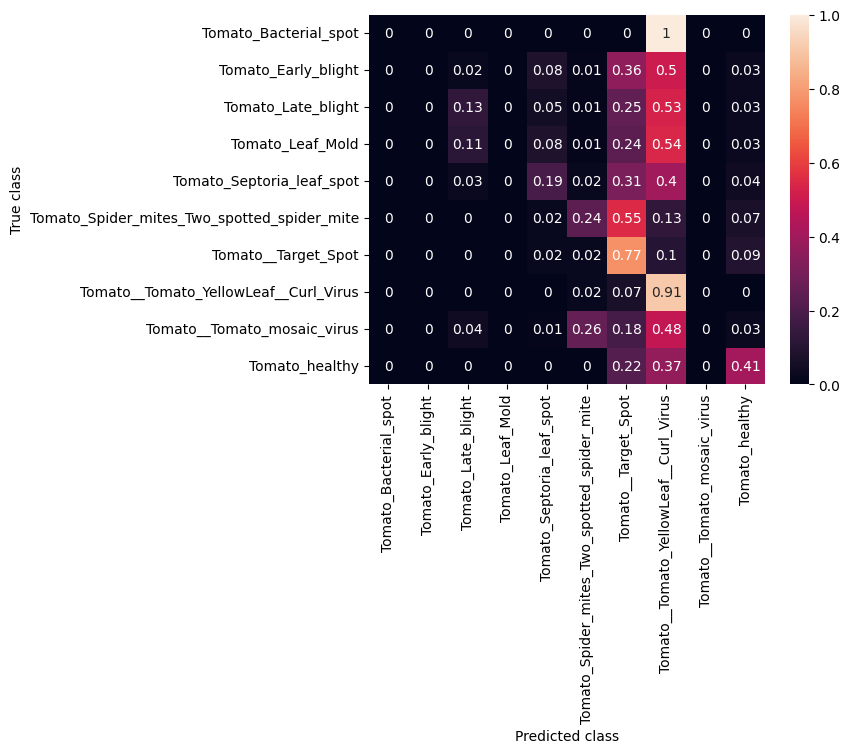

In [28]:
sns.heatmap(cm_normalized, annot=True,xticklabels=class_name, yticklabels=class_name,)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.savefig('resnet50_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
import pickle
# Save the history object to a file
with open('history_resnet50.pkl', 'wb') as file:
    pickle.dump(history.history, file)